**Name:** Yani Xu
**Email:** xu.6406@osu.edu
**Tutorial:** Machine Learning in Python Step-By-Step by Jason Brownlee
**Source:** https://machinelearningmastery.com/machine-learning-in-python-step-by-step/


# Machine Learning Project in Python
A complete end-to-end ML project on the Iris dataset, following the tutorial by Jason Brownlee.

1. Import libraries
2. Load dataset
3. Summarize dataset
4. Visualize dataset
5. Evaluate algorithms
6. Make predictions


In [1]:
%matplotlib inline
import sys
print('Python:', sys.version)
import scipy
print('scipy:', scipy.__version__)
import numpy
print('numpy:', numpy.__version__)
import matplotlib
print('matplotlib:', matplotlib.__version__)
import pandas
print('pandas:', pandas.__version__)
import sklearn
print('sklearn:', sklearn.__version__)
from pandas import read_csv
from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


Python: 3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:12:50) [MSC v.1942 64 bit (AMD64)]


scipy: 1.18.0
numpy: 2.5.0
matplotlib: 3.11.0


pandas: 3.0.3


sklearn: 1.9.0


## 2. Load Dataset
The Iris dataset contains 150 observations with 4 features and 3 species.


In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/iris.csv'
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'class']
dataset = read_csv(url, names=names)


## 3. Summarize Dataset


In [3]:
print('Shape:', dataset.shape)
dataset.head()


Shape: (150, 5)


,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
dataset.describe()


,sepal-length,sepal-width,petal-length,petal-width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
dataset.groupby('class').size()


class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64

## 4. Data Visualization


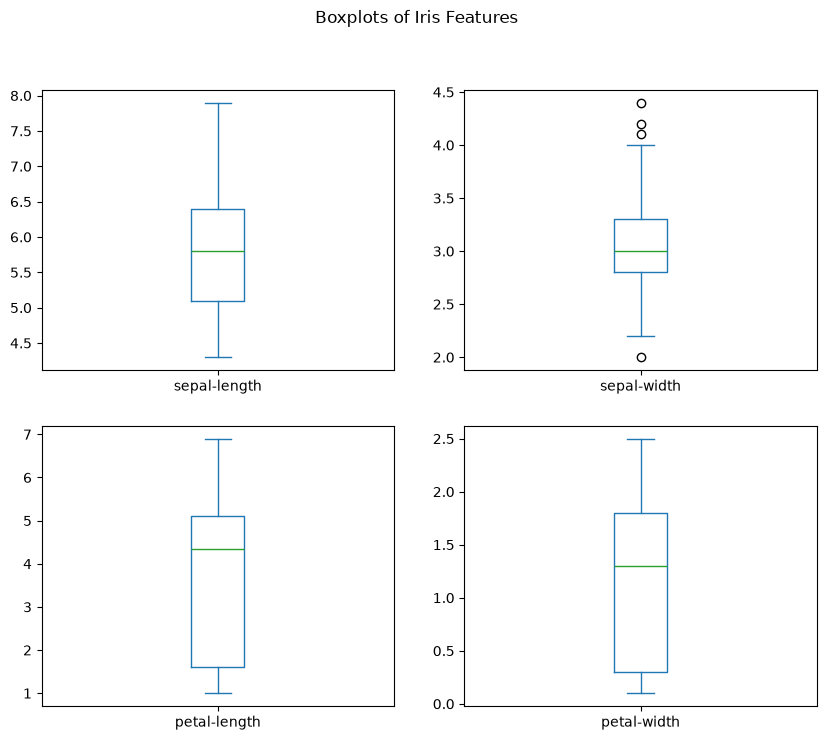

In [6]:
dataset.plot(kind='box', subplots=True, layout=(2,2), figsize=(10,8))
plt.suptitle('Boxplots of Iris Features')
plt.show()


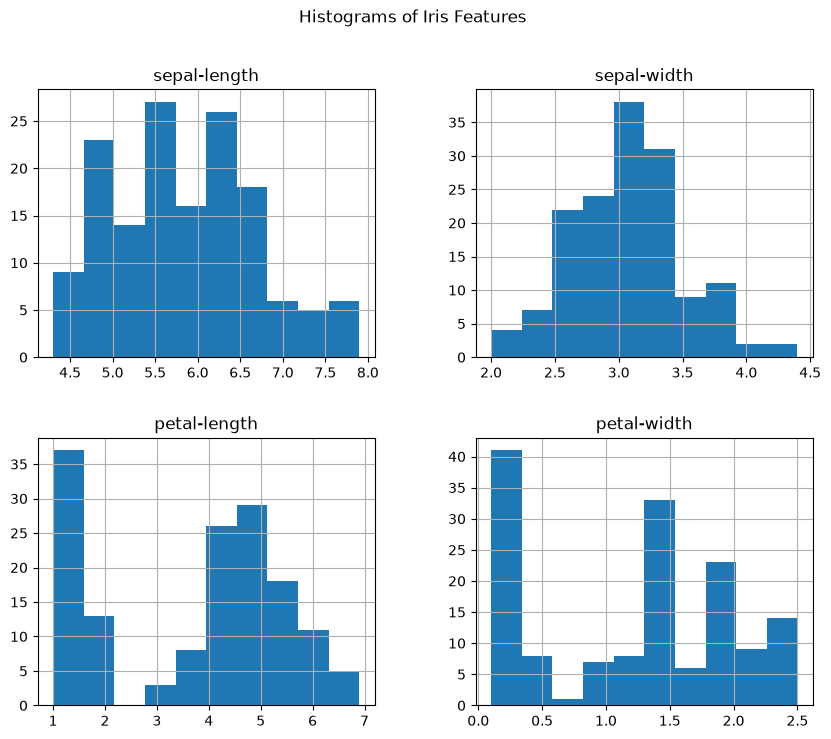

In [7]:
dataset.hist(figsize=(10,8))
plt.suptitle('Histograms of Iris Features')
plt.show()


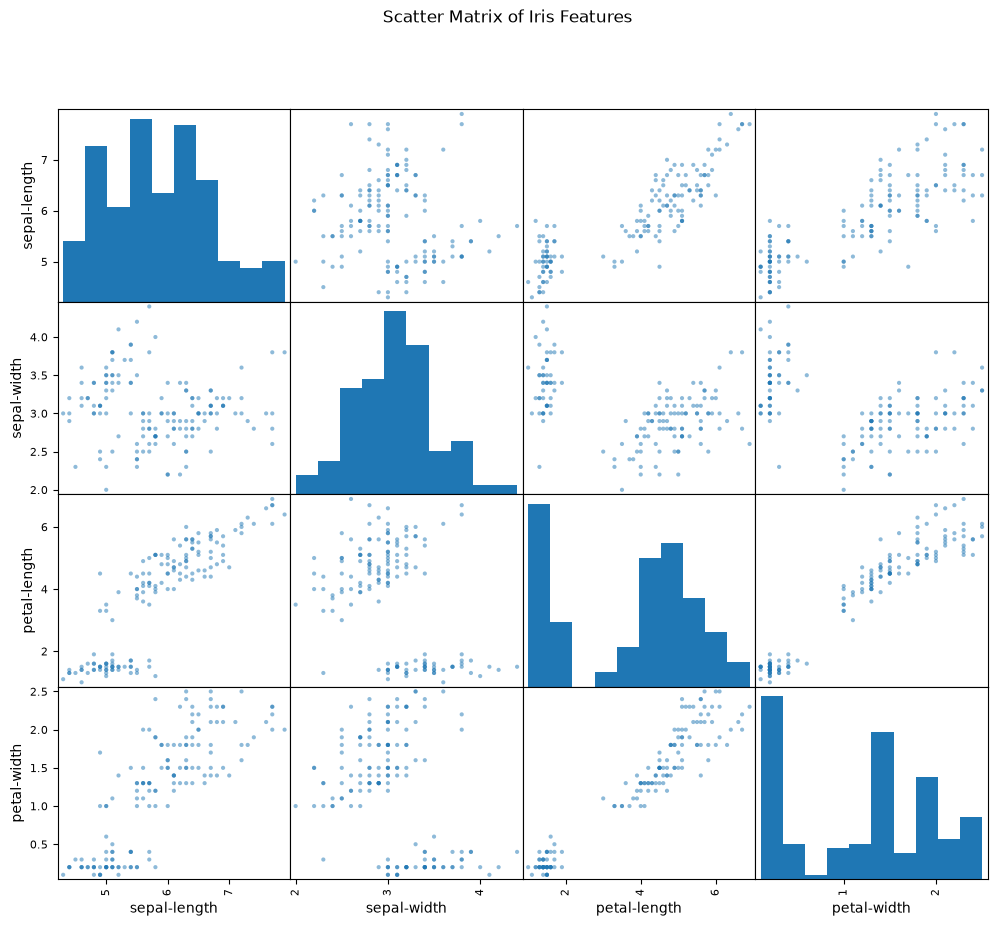

In [8]:
scatter_matrix(dataset, figsize=(12,10))
plt.suptitle('Scatter Matrix of Iris Features')
plt.show()


## 5. Evaluate Algorithms
We split data 80/20 and evaluate 6 models using 10-fold cross-validation.


In [9]:
array = dataset.values
X = array[:,0:4].astype(float)
y = array[:,4]
X_train, X_val, Y_train, Y_val = train_test_split(X, y, test_size=0.20, random_state=1)
models = [('LR', LogisticRegression(max_iter=200)),
          ('LDA', LinearDiscriminantAnalysis()),
          ('KNN', KNeighborsClassifier()),
          ('CART', DecisionTreeClassifier()),
          ('NB', GaussianNB()),
          ('SVM', SVC(gamma='auto'))]
results = []; names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
    results.append(cv); names.append(name)
    print(f'{name}: {cv.mean():.4f} ({cv.std():.4f})')


LR: 0.9667 (0.0408)
LDA: 0.9750 (0.0382)
KNN: 0.9583 (0.0417)
CART: 0.9417 (0.0534)
NB: 0.9500 (0.0553)
SVM: 0.9833 (0.0333)


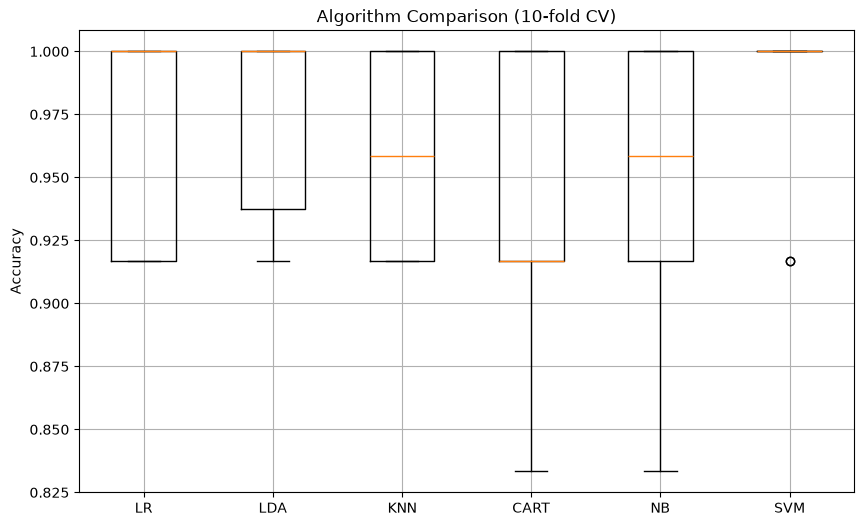

In [10]:
plt.figure(figsize=(10,6))
plt.boxplot(results, tick_labels=names)
plt.title('Algorithm Comparison (10-fold CV)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()


## 6. Make Predictions
Train the best model on full training set and evaluate on held-out validation set.


In [11]:
model = SVC(gamma='auto')
model.fit(X_train, Y_train)
predictions = model.predict(X_val)
print('Accuracy:', accuracy_score(Y_val, predictions))
print('Confusion Matrix:')
print(confusion_matrix(Y_val, predictions))
print('Classification Report:')
print(classification_report(Y_val, predictions))


Accuracy: 0.9666666666666667
Confusion Matrix:
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.97        30
      macro avg       0.95      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30



## Summary
Complete end-to-end ML workflow in Python: data loading, exploration, visualization, cross-validation, and prediction.
